# 3. Alpha and Beta Diversity

In this notebook we calculate metrics for the alpha and beta diversity on the original, normalized data.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal

meta = pd.read_csv("../data/processed/metadata_final.tsv", sep="\t", index_col="Sample")
genera_clr = pd.read_csv("../data/processed/genera_clr.tsv", sep="\t", index_col=0)

print("Metadata shape:", meta.shape)
print("Genera CLR shape:", genera_clr.shape)

Metadata shape: (105, 23)
Genera CLR shape: (105, 2761)


## Alpha diversity

Alpha diversity is used to measure how diverse a gut-microbiome sample is. It captures the richness in species and evenness (how balanced are the species). A metric used to measure alpha diversity is the shannon index:

$$
H = - \sum_{i=1}^{S} p_i \log(p_i)
$$


In the following results for the alpha diversity a high score means a diverse, balanced microbiome, while a low score means few bacteria dominate.

In [9]:
# We calculate Shannon on the ORIGINAL normalized data, not CLR
# Reload the pre-CLR normalized genera
meta_base = pd.read_csv("../data/processed/metadata_baseline.tsv", sep="\t")
genera_base = pd.read_csv("../data/processed/genera_baseline.tsv", sep="\t", index_col=0)

# Filter and normalize again (same steps as the preprocessing part)
prevalence = (genera_base > 0).mean()
genera_filtered = genera_base.loc[:, prevalence >= 0.10]
genera_norm = genera_filtered.div(genera_filtered.sum(axis=1), axis=0)

# Shannon Index: H = -sum(p * log(p))
def shannon_index(row):
    p = row[row > 0]  # ignore zeros for log
    return -np.sum(p * np.log(p))

shannon = genera_norm.apply(shannon_index, axis=1)
meta_base = meta_base.set_index("Sample")
meta_base["shannon"] = shannon

print("Shannon diversity calculated for", len(shannon), "subjects")
print(shannon.describe().round(3))

Shannon diversity calculated for 105 subjects
count    105.000
mean       2.263
std        0.593
min        0.614
25%        1.879
50%        2.258
75%        2.582
max        4.116
dtype: float64


/tmp/ipykernel_6190/2200657412.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=meta_base, x="Gender", y="shannon",
/tmp/ipykernel_6190/2200657412.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=meta_base, x="Gender", y="shannon",
/tmp/ipykernel_6190/2200657412.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=meta_base, x="Study.Group", y="shannon",
/tmp/ipykernel_6190/2200657412.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable 

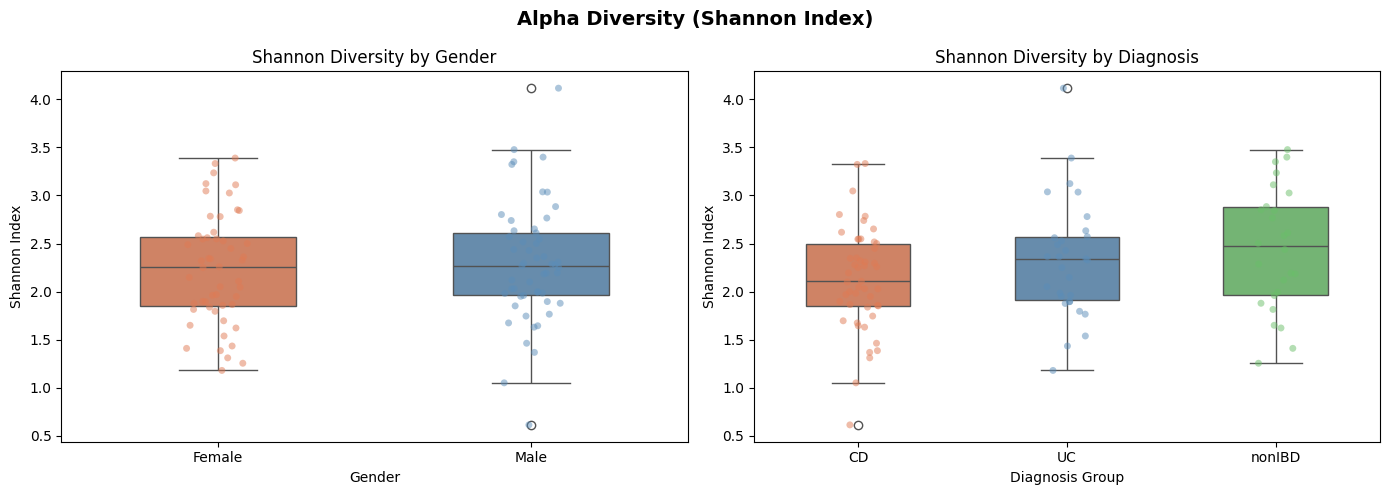

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Alpha Diversity (Shannon Index)", fontsize=14, fontweight="bold")

# By Gender
sns.boxplot(data=meta_base, x="Gender", y="shannon",
            palette={"Male": "#5b8db8", "Female": "#e07b54"},
            ax=axes[0], width=0.5)
sns.stripplot(data=meta_base, x="Gender", y="shannon",
              palette={"Male": "#5b8db8", "Female": "#e07b54"},
              ax=axes[0], alpha=0.5, jitter=True)
axes[0].set_title("Shannon Diversity by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Shannon Index")

# By Diagnosis
sns.boxplot(data=meta_base, x="Study.Group", y="shannon",
            palette={"CD": "#e07b54", "UC": "#5b8db8", "nonIBD": "#6abf69"},
            ax=axes[1], width=0.5)
sns.stripplot(data=meta_base, x="Study.Group", y="shannon",
              palette={"CD": "#e07b54", "UC": "#5b8db8", "nonIBD": "#6abf69"},
              ax=axes[1], alpha=0.5, jitter=True)
axes[1].set_title("Shannon Diversity by Diagnosis")
axes[1].set_xlabel("Diagnosis Group")
axes[1].set_ylabel("Shannon Index")

plt.tight_layout()
plt.savefig("../results/figures/08_shannon_diversity.png", dpi=150)
plt.show()

In [11]:
male_shannon = meta_base[meta_base["Gender"] == "Male"]["shannon"]
female_shannon = meta_base[meta_base["Gender"] == "Female"]["shannon"]

stat, p = mannwhitneyu(male_shannon, female_shannon, alternative="two-sided")
print("=== Gender difference in Shannon diversity ===")
print(f"Male   mean: {male_shannon.mean():.3f}")
print(f"Female mean: {female_shannon.mean():.3f}")
print(f"Mann-Whitney U statistic: {stat:.1f}")
print(f"p-value: {p:.4f}")
print(f"Significant (p<0.05): {p < 0.05}")

print()

# Also test across diagnosis groups
cd = meta_base[meta_base["Study.Group"] == "CD"]["shannon"]
uc = meta_base[meta_base["Study.Group"] == "UC"]["shannon"]
nonIBD = meta_base[meta_base["Study.Group"] == "nonIBD"]["shannon"]

stat_k, p_k = kruskal(cd, uc, nonIBD)
print("=== Diagnosis difference in Shannon diversity ===")
print(f"CD     mean: {cd.mean():.3f}")
print(f"UC     mean: {uc.mean():.3f}")
print(f"nonIBD mean: {nonIBD.mean():.3f}")
print(f"Kruskal-Wallis statistic: {stat_k:.1f}")
print(f"p-value: {p_k:.4f}")
print(f"Significant (p<0.05): {p_k < 0.05}")

=== Gender difference in Shannon diversity ===
Male   mean: 2.293
Female mean: 2.233
Mann-Whitney U statistic: 1459.0
p-value: 0.6059
Significant (p<0.05): False

=== Diagnosis difference in Shannon diversity ===
CD     mean: 2.130
UC     mean: 2.327
nonIBD mean: 2.440
Kruskal-Wallis statistic: 4.2
p-value: 0.1219
Significant (p<0.05): False


### Comments on Alpha diversity

After calculating shannon diversity, we use Mann-Whitney U (for 2 groups) and Kruskal-Wallis (for 3 groups) tests. They are non-parametric and do not assume the data follows a normal distribution. The process followed for these tests is combining all values, ranking them and then comparing how the ranks are distributed between the groups.

To use the results of these tests we also calculate the p-value. This value in calculated shuffling labels assuming no difference between groups and then computing statistically how often we get something as extreme as the results we have. If the final value is smaller it means we have a more significant difference and the groups are likely different.

In our result we do not have evidence the microbiome in our dataset differs by gender. For the diagnosis we can observe an interesting trend on the means (CD<UC<nonIBD) although it does not seem strong enough to be statistically significant.

## Beta Diversity

Beta diversity is used to measure how different microbiome samples from subjects are from each other. We have already CLR-transformed data and the euclidean distance in the CLR space is called Aichinson distance. To present a visualization for this distance we perform PCA (we keep 2 the 2 dimensions that show the biggest variation) to show the distances on 2 dimenstions. In the plots that follow close points mean a similar microbiome and far points different microbiomes.

Following the Beta Diversity analysis we will then compute the Bray-Curtis dissimilarity, which measures how different are two samples based on their abundances. A number close to 0 means almost identical samples (small distance) and a number close to 1 (large distance) shows complete difference between the samples. The output number is in [0, 1] because it is normalized, showing the difference relative to the size.

Important Note: We use Bray-Curtis on the normalized data, not on the CLR transformed ones.



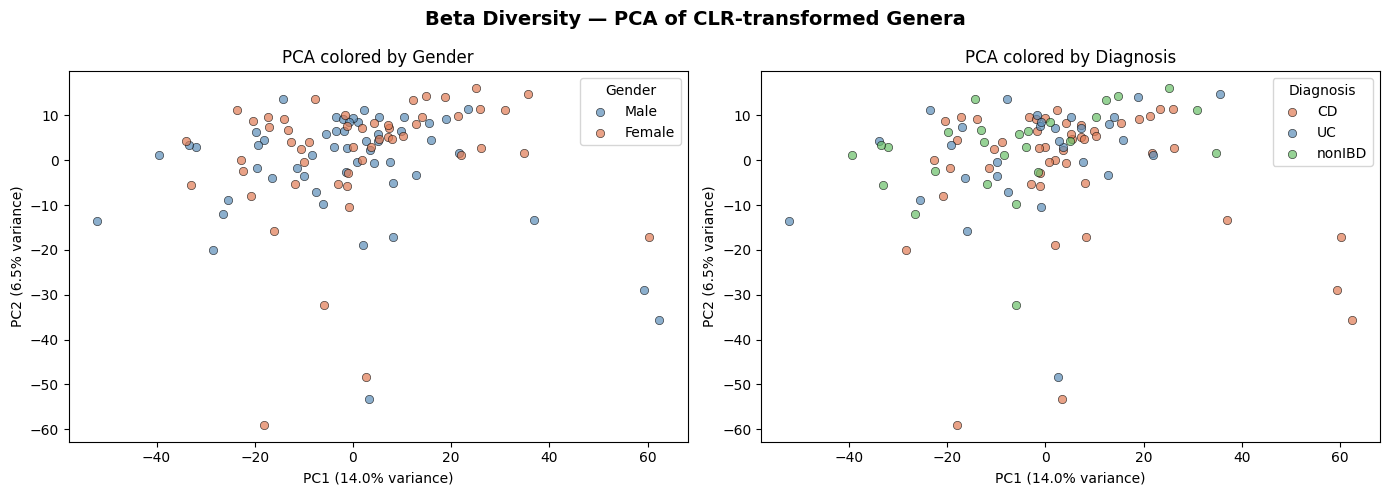

PC1 explains: 14.0% of variance
PC2 explains: 6.5% of variance
Total explained: 20.6%


In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# PCA on CLR-transformed data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(genera_clr)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "Gender": meta_base["Gender"].values,
    "Diagnosis": meta_base["Study.Group"].values
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Beta Diversity — PCA of CLR-transformed Genera", fontsize=14, fontweight="bold")

# Colored by Gender
for gender, color in zip(["Male", "Female"], ["#5b8db8", "#e07b54"]):
    subset = pca_df[pca_df["Gender"] == gender]
    axes[0].scatter(subset["PC1"], subset["PC2"], label=gender,
                    color=color, alpha=0.7, edgecolors="black", linewidths=0.5)
axes[0].set_title("PCA colored by Gender")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[0].legend(title="Gender")

# Colored by Diagnosis
colors_dx = {"CD": "#e07b54", "UC": "#5b8db8", "nonIBD": "#6abf69"}
for dx, color in colors_dx.items():
    subset = pca_df[pca_df["Diagnosis"] == dx]
    axes[1].scatter(subset["PC1"], subset["PC2"], label=dx,
                    color=color, alpha=0.7, edgecolors="black", linewidths=0.5)
axes[1].set_title("PCA colored by Diagnosis")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[1].legend(title="Diagnosis")

plt.tight_layout()
plt.savefig("../results/figures/09_pca_beta_diversity.png", dpi=150)
plt.show()

print(f"PC1 explains: {pca.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]*100:.1f}% of variance")
print(f"Total explained: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%")

In [6]:
from sklearn.metrics import pairwise_distances
from skbio.stats.distance import DistanceMatrix, permanova

# Calculate Bray-Curtis dissimilarity matrix
bray_curtis = pairwise_distances(genera_norm.values, metric="braycurtis")
sample_ids = list(genera_norm.index.astype(str))
dm = DistanceMatrix(bray_curtis, ids=sample_ids)

# PERMANOVA by Gender
labels_gender = meta_base["Gender"].astype(str).values
result_gender = permanova(dm, labels_gender, permutations=999)
R2_gender = result_gender["test statistic"]
p_gender = result_gender["p-value"]

print("=== PERMANOVA: Gender ===")
print(result_gender)

# PERMANOVA by Diagnosis
labels_dx = meta_base["Study.Group"].astype(str).values
result_dx = permanova(dm, labels_dx, permutations=999)
R2_dx = result_dx["test statistic"]
p_dx = result_dx["p-value"]

print("\n=== PERMANOVA: Diagnosis ===")
print(result_dx)

=== PERMANOVA: Gender ===
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     105
number of groups                  2
test statistic             1.098133
p-value                       0.345
number of permutations          999
Name: PERMANOVA results, dtype: object

=== PERMANOVA: Diagnosis ===
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     105
number of groups                  3
test statistic             1.329943
p-value                       0.153
number of permutations          999
Name: PERMANOVA results, dtype: object


/home/jimkam/Desktop/BioMedProject/bioenv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/jimkam/Desktop/BioMedProject/bioenv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/jimkam/Desktop/BioMedProject/bioenv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


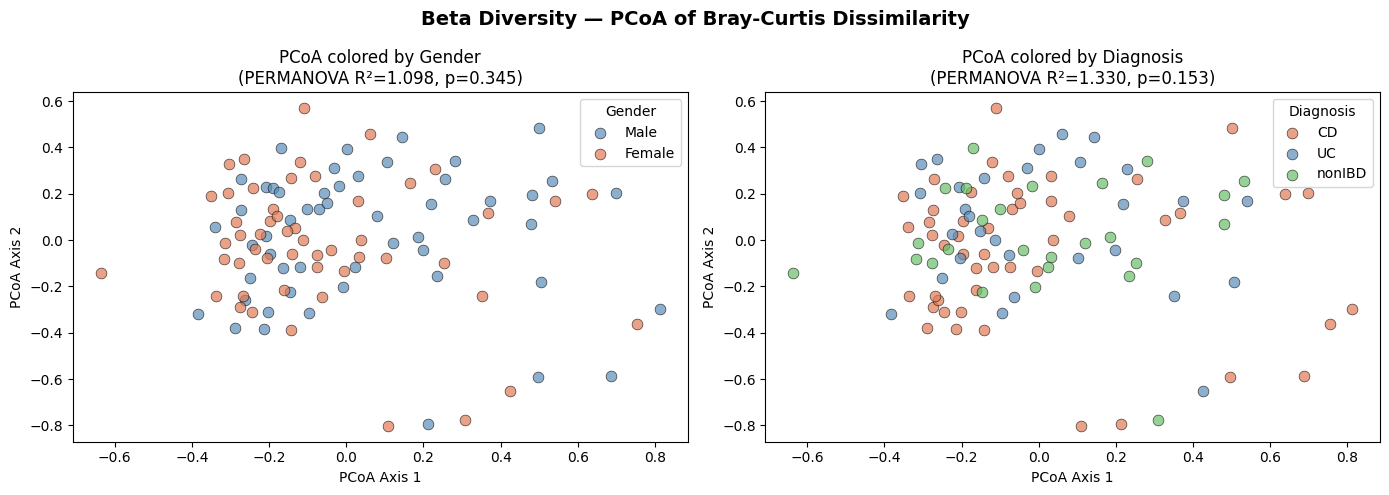

In [7]:
from sklearn.manifold import MDS

# PCoA = MDS applied to a distance matrix
pcoa = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = pcoa.fit_transform(bray_curtis)

pcoa_df = pd.DataFrame({
    "PCoA1": coords[:, 0],
    "PCoA2": coords[:, 1],
    "Gender": meta_base["Gender"].values,
    "Diagnosis": meta_base["Study.Group"].values
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Beta Diversity — PCoA of Bray-Curtis Dissimilarity", 
             fontsize=14, fontweight="bold")

# Colored by Gender
for gender, color in zip(["Male", "Female"], ["#5b8db8", "#e07b54"]):
    subset = pcoa_df[pcoa_df["Gender"] == gender]
    axes[0].scatter(subset["PCoA1"], subset["PCoA2"], label=gender,
                    color=color, alpha=0.7, edgecolors="black", linewidths=0.5, s=60)
axes[0].set_title(f"PCoA colored by Gender\n(PERMANOVA R²={R2_gender:.3f}, p={p_gender:.3f})")
axes[0].set_xlabel("PCoA Axis 1")
axes[0].set_ylabel("PCoA Axis 2")
axes[0].legend(title="Gender")

# Colored by Diagnosis
colors_dx = {"CD": "#e07b54", "UC": "#5b8db8", "nonIBD": "#6abf69"}
for dx, color in colors_dx.items():
    subset = pcoa_df[pcoa_df["Diagnosis"] == dx]
    axes[1].scatter(subset["PCoA1"], subset["PCoA2"], label=dx,
                    color=color, alpha=0.7, edgecolors="black", linewidths=0.5, s=60)
axes[1].set_title(f"PCoA colored by Diagnosis\n(PERMANOVA R²={R2_dx:.3f}, p={p_dx:.3f})")
axes[1].set_xlabel("PCoA Axis 1")
axes[1].set_ylabel("PCoA Axis 2")
axes[1].legend(title="Diagnosis")

plt.tight_layout()
plt.savefig("../results/figures/10_pcoa_beta_diversity.png", dpi=150)
plt.show()

## Comments on Beta Diversity

From PCA analysis and the Bray-Curtis dissimilarity matrix metrics we can assume that 2 random patients share almost half the microbiome and also there is no significant difference between genders.

After the Bray-Curtis dissimilarity we can use the pseudo-F and p values to extract more. Pseudo-F measures the ratio of between-group to within-group variation, with higher meaning better separation. On our analysis we cannot see large separation on either gender or diagnosis, with diagnosis having a little more difference bwtween the categories.

